In [13]:
#!/usr/bin/env python
import matplotlib.pyplot as plt
import numpy as np
from lmfit.models import LorentzianModel, QuadraticModel, VoigtModel, LinearModel,PseudoVoigtModel
import pandas as pd


def add_peak(prefix, center, amplitude=0.1, sigma=0.05,gamma = 0.05):
    peak = VoigtModel(prefix=prefix)
    pars = peak.make_params()
    pars[prefix + 'center'].set(center,min=2000,max =2200)
    pars[prefix + 'amplitude'].set(amplitude, min = 0.01,max=500)
    pars[prefix + 'sigma'].set(sigma, min=0.001,max =40)
    pars[prefix + 'gamma'].set(gamma, min=0, max=100,vary = True)
    return peak, pars
def add_fancy_peak(prefix, center, amplitude, fwhm, fraction = 0.5):
    peak = PseudoVoigtModel(prefix=prefix)
    pars = peak.make_params()
    pars[prefix + 'center'].set(center,min=center-10,max =center+10)
    pars[prefix + 'amplitude'].set(amplitude, min = 0,max=10)
    #pars[prefix + 'fwhm'].set(fwhm,min=fwhm-5,max =fwhm+5,vary=True,expr=None)
    pars[prefix + 'fraction'].set(fraction, min=0, max=1)
    pars[prefix + 'sigma'].set(fwhm/2,min=fwhm/2-10,max =fwhm/2+10)
    return peak, pars


4149
4978
4149    2000.094
4150    2000.335
4151    2000.576
4152    2000.817
4153    2001.058
          ...   
4973    2198.729
4974    2198.970
4975    2199.211
4976    2199.452
4977    2199.693
Name: wavenum, Length: 829, dtype: float64
4149    0.001710
4150    0.001731
4151    0.001755
4152    0.001776
4153    0.001792
          ...   
4973    0.000903
4974    0.000937
4975    0.000971
4976    0.000996
4977    0.001007
Name: val, Length: 829, dtype: float64


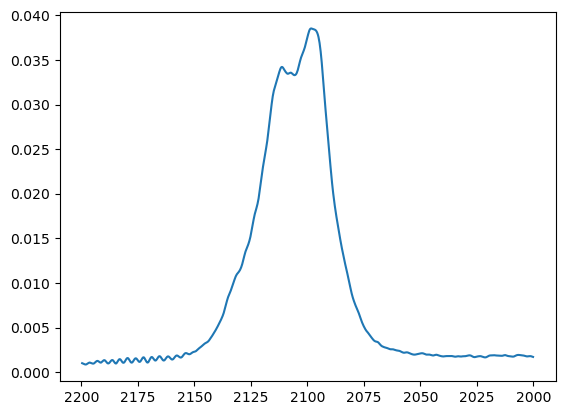

In [10]:
# Choose .csv data file and turn it into dataframe
colnames = ["wavenum" , "val"] #Defines the column tites for a csv without titles
# Edit the CSV Name here for your first file
file = pd.read_csv('240805_CuAl2O31per_CO100PPM_60min.csv', names = colnames) #,header=[0,1]) 
drifts_df = pd.DataFrame(file)
#This works for the CSV that is exported from the OMNIC software, where Wavenumber is the first column and the Units are the second column
#All CSVs imported together must have the same Wavenumber range! (Future code will be able to handle data with different ranges]
wavenum = drifts_df.iloc[:, 0]
#This step adds all the Data name, the data, and whether you want it to be included in the current plot with a true false statement. 
#This info is added as a list to a large list that compiles all your data
#The data name is used as the legend name for the data
datalist = [["300C",drifts_df.iloc[:, 1], True]]
#Change true to false for any one you want to exclude from a given plot.
wn1 = 2000 # Start in wn
wn2= 2200 # End in wn
#Finds the location of that wavenumber in the index
wn1_df = wavenum.iloc[(wavenum-wn1).abs().argsort()[:1]].index[0]
wn2_df = wavenum.iloc[(wavenum-wn2).abs().argsort()[:1]].index[0] 
print(wn1_df)
print(wn2_df)
xdat = wavenum.iloc[wn1_df:wn2_df]
ydat = datalist[0][1].iloc[wn1_df:wn2_df]
print(xdat)
print(ydat)
plt.plot(xdat, ydat, label='data')
plt.gca().invert_xaxis()

In [ ]:
model = LinearModel(prefix='bkg_')
params = model.make_params(a=0, b=0)

rough_peak_positions = (2125,2114,2096)
for i, cen in enumerate(rough_peak_positions):
    peak, pars = add_peak('lz%d_' % (i+1), cen)
    model = model + peak
    params.update(pars)

init = model.eval(params, x=xdat)
result = model.fit(ydat, params, x=xdat)
comps = result.eval_components()

print(result.fit_report(min_correl=0.5))


In [23]:
model = LinearModel(prefix='bkg_')
params = model.make_params(m=-5.5513e-07 , b=0.00108225)

rough_peak_positions = (2097,2114,2125)

rough_fwhm = (16.6,16.8,29.0)
rough_ampl = (0.4,0.2,-.005)
for i, cen in enumerate(rough_peak_positions):
    peak, pars = add_fancy_peak('lz%d_' % (i+1), cen, rough_ampl[i],rough_fwhm[i])
    model = model + peak
    params.update(pars)

init = model.eval(params, x=xdat)
result = model.fit(ydat, params, x=xdat)
comps = result.eval_components()
fit_areas = {}
for name, comp in comps.items():
    fit_areas[name] = np.trapz(y = comp, x = xdat) 
print(result.fit_report(min_correl=0.5))
print(fit_areas)

[[Model]]
    (((Model(linear, prefix='bkg_') + Model(pvoigt, prefix='lz1_')) + Model(pvoigt, prefix='lz2_')) + Model(pvoigt, prefix='lz3_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 476
    # data points      = 829
    # variables        = 14
    chi-square         = 6.5548e-05
    reduced chi-square = 8.0427e-08
    Akaike info crit   = -13528.5924
    Bayesian info crit = -13462.5093
    R-squared          = 0.99938426
[[Variables]]
    bkg_slope:     -2.9615e-06 +/- 2.1753e-07 (7.35%) (init = 1)
    bkg_intercept:  0.00724089 +/- 4.4780e-04 (6.18%) (init = 0)
    lz1_amplitude:  0.90665562 +/- 0.02715836 (3.00%) (init = 0.4)
    lz1_center:     2096.74121 +/- 0.10561662 (0.01%) (init = 2097)
    lz1_sigma:      8.95216927 +/- 0.07314241 (0.82%) (init = 8.3)
    lz1_fraction:   0.81059738 +/- 0.01035626 (1.28%) (init = 0.5)
    lz1_fwhm:       17.9043385 +/- 0.14628481 (0.82%) == '2.0000000*lz1_sigma'
    lz1_height:     0.03514208 +/- 7.7347e-04 

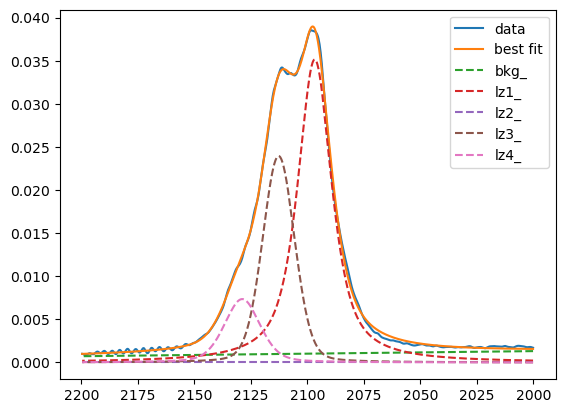

In [22]:
plt.plot(xdat, ydat, label='data')
plt.plot(xdat, result.best_fit, label='best fit')
for name, comp in comps.items():
    plt.plot(xdat, comp, '--', label=name)
plt.gca().invert_xaxis()
plt.legend(loc='upper right')
plt.show()

In [9]:
fit_dict = {"data":ydat.values, "best fit":result.best_fit}
for name, comp in comps.items():
    fit_dict[name] = comp
df_fit =pd.DataFrame(fit_dict,index=xdat)
df_fit.to_csv("240703_CuRh0.04_RT post CO 30 min_30 C backrgound 21" + "Best_Fit2000_2200.csv",',')
f = open("240703_CuRh0.04_RT post CO 30 min_30 C backrgound 21" + "Best_Fit2000_2200.txt", "w")
f.write(result.fit_report(min_correl=0.5))
f.close()

In [ ]:
df_fit